# Auditoría de licencias: ¿qué se anuncia sin licencia válida?

Responde a la pregunta central de **[M-08]** en `docs/prd.md`: hasta qué punto puede identificarse la oferta anunciada **sin licencia válida**.

La diferencia con `02_exploracion_airbnb.ipynb` es el paso decisivo: allí se audita si el anuncio **declara** algo en el campo `license`; aquí se comprueba si lo que declara **existe en el registro oficial**.

> Este notebook **no reimplementa** la clasificación: lee la salida de `pipeline/transform/auditar_licencias.py`. Así el criterio vive en un solo sitio y no puede divergir entre el análisis y el pipeline.

```bash
python pipeline/transform/auditar_licencias.py
```

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path('../..')
pd.set_option('display.max_columns', None)

d = pd.read_csv(RAIZ / 'data/processed/airbnb_situacion_licencia.csv')
sujetos = d[d['sujeto_a_vut']]
candidatos = d[d['candidato_sin_licencia']]

print(f'Anuncios              : {len(d):,}')
print(f'Sujetos al régimen VUT: {len(sujetos):,}')
print(f'Candidatos            : {len(candidatos):,}')

Anuncios              : 15,406
Sujetos al régimen VUT: 8,996
Candidatos            : 1,887


## 1. Tres trampas del campo `license`

Las tres se encontraron sobre los datos reales, y cada una alteraba el resultado.

### Trampa 1 — el campo contiene dos números

```
Spain - National registration number
ESFCTU000008058000039706000000000000000HUTB-002062349   ← incrusta el HUTB + dígitos de control
Barcelona - Regional registration number
HUTB-002062                                             ← el número real
```

Buscar `HUTB-\d+` en todo el campo captura el nacional y devuelve un HUTB inexistente. Ese error elevaba las licencias "no encontradas" del **14,8% al 36,2%**.

### Trampa 2 — la sección regional no solo lleva HUTB

También aparecen licencias de otros regímenes. Un anuncio con una de estas **sí está acreditado**, solo que no como vivienda de uso turístico.

In [2]:
print('Regímenes declarados en la sección regional:')
print(d['prefijo_licencia'].value_counts().to_string())
print(f"\nAnuncios con licencia de otro régimen: {(d['regimen_declarado'].notna()).sum():,}")
print(d['regimen_declarado'].value_counts().to_string())
print('\n→ Tratarlos como "no declara nada" inflaba los candidatos en 74 anuncios.')

Regímenes declarados en la sección regional:
prefijo_licencia
HUTB    7228
HB       670
AJ       203
ATB       28

Anuncios con licencia de otro régimen: 901
regimen_declarado
hotel                  670
alberg                 203
apartament_turistic     28

→ Tratarlos como "no declara nada" inflaba los candidatos en 74 anuncios.


### Trampa 3 — no toda la oferta necesita licencia VUT

La normativa catalana define estancia turística como *"període de temps continu igual o inferior a 31 dies"*: hasta 31 noches es uso turístico y exige licencia; a partir de 32 es alquiler de temporada y queda fuera. Una habitación en vivienda habitual se rige por otro régimen.

Por eso se acota el universo **antes** de contar: contar habitaciones o alquileres largos como irregulares sería sencillamente incorrecto.

In [3]:
universo = pd.DataFrame({
    'anuncios': [
        len(d),
        (d['room_type'] != 'Entire home/apt').sum(),
        ((d['room_type'] == 'Entire home/apt') & (d['minimum_nights'] > 31)).sum(),
        len(sujetos),
    ]},
    index=['Total en Airbnb', '— habitaciones (otro régimen)',
           '— vivienda completa 32+ noches (temporada)', '= Sujetos al régimen VUT'])
universo

,anuncios
Total en Airbnb,15406
— habitaciones (otro régimen),4562
— vivienda completa 32+ noches (temporada),1847
= Sujetos al régimen VUT,8996


## 2. Situación de los anuncios sujetos a licencia VUT

In [4]:
resumen = sujetos['situacion'].value_counts().to_frame('anuncios')
resumen['%'] = (resumen['anuncios'] / len(sujetos) * 100).round(1)
resumen

,anuncios,%
situacion,,
licencia_verificada,6006,66.8
sin_declarar,1366,15.2
exencion_declarada,1029,11.4
licencia_no_encontrada,521,5.8
licencia_otro_regimen,74,0.8


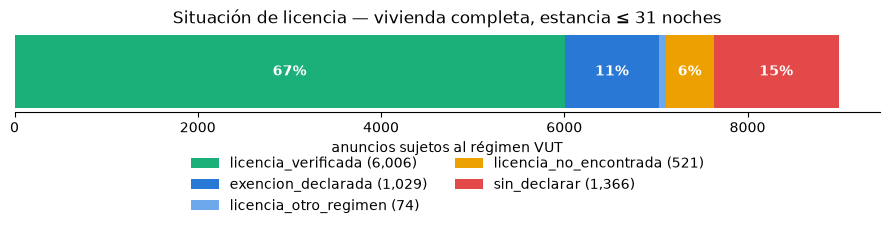

In [5]:
orden = ['licencia_verificada', 'exencion_declarada', 'licencia_otro_regimen',
         'licencia_no_encontrada', 'sin_declarar']
colores = ['#1baf7a', '#2a78d6', '#6da7ec', '#eda100', '#e34948']
datos = sujetos['situacion'].value_counts().reindex(orden).fillna(0)

fig, ax = plt.subplots(figsize=(9, 3))
izq = 0
for etiqueta, valor, color in zip(orden, datos, colores):
    ax.barh(0, valor, left=izq, color=color, label=f'{etiqueta} ({int(valor):,})')
    if valor > 400:
        ax.text(izq + valor / 2, 0, f'{valor / datos.sum():.0%}', ha='center', va='center',
                color='white', fontweight='bold')
    izq += valor
ax.set_yticks([])
ax.set_xlabel('anuncios sujetos al régimen VUT')
ax.set_title('Situación de licencia — vivienda completa, estancia ≤ 31 noches')
ax.legend(bbox_to_anchor=(0.5, -0.4), loc='upper center', ncol=2, frameon=False)
for lado in ('top', 'right', 'left'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

## 3. La cifra tiene capas

El total de candidatos es el techo, no la conclusión. Dos matices lo reducen sustancialmente, y conviene enseñarlos juntos en vez de elegir el número que más conviene.

In [6]:
en_frontera = candidatos['minimum_nights'] == 31
activos = candidatos['actividad_reciente']
nucleo = candidatos[activos & ~en_frontera]

capas = pd.DataFrame({
    'anuncios': [
        len(candidatos),
        len(candidatos[~activos]),
        int(en_frontera.sum()),
        len(nucleo),
    ]},
    index=['Candidatos (techo)',
           '— sin reseñas o anteriores a 2025 (posibles inactivos)',
           '— con estancia mínima de exactamente 31 noches (frontera legal)',
           '= Núcleo: activos y fuera de la frontera'])
capas

,anuncios
Candidatos (techo),1887
— sin reseñas o anteriores a 2025 (posibles inactivos),830
— con estancia mínima de exactamente 31 noches (frontera legal),828
= Núcleo: activos y fuera de la frontera,727


**Los 31 noches exactos merecen atención aparte.** No es casualidad: es el último valor que sigue dentro del régimen VUT. Un solo día más y quedarían exentos como alquiler de temporada. Un operador concentra casi todos.

In [7]:
frontera = candidatos[en_frontera]
print(f'Candidatos con exactamente 31 noches mínimas: {len(frontera):,}')
print('\nAnfitriones que los concentran:')
print(frontera.groupby('host_name').size().sort_values(ascending=False).head(5).to_string())
print('\nDistribución de noches mínimas en el resto de candidatos:')
print(candidatos.loc[~en_frontera, 'minimum_nights'].value_counts().sort_index().head(8).to_string())

Candidatos con exactamente 31 noches mínimas: 828

Anfitriones que los concentran:
host_name
Ukio                 352
Marc                  38
Caterina              30
Silvia De Lourdes     26
Iñaki                 15

Distribución de noches mínimas en el resto de candidatos:
minimum_nights
1.0    466
2.0    245
3.0     97
4.0     31
5.0     20
6.0      5
7.0      5
8.0      3


## 4. Licencias declaradas que no pueden existir

Un número por encima del último emitido por la Generalitat no admite la explicación del error de tecleo.

In [8]:
imposibles = d[d['fuera_de_rango']]
print(f'Licencias declaradas fuera del rango emitido: {len(imposibles):,}')
print(f'  de ellas, en anuncios sujetos a VUT       : {imposibles["sujeto_a_vut"].sum():,}')
print('\nEjemplos de números declarados:')
print(sorted(imposibles['hutb'].dropna().unique())[-10:])

Licencias declaradas fuera del rango emitido: 889
  de ellas, en anuncios sujetos a VUT       : 395

Ejemplos de números declarados:
['HUTB-973421', 'HUTB-973555', 'HUTB-984910', 'HUTB-985436', 'HUTB-987000', 'HUTB-987654', 'HUTB-987890', 'HUTB-988770', 'HUTB-990666', 'HUTB-995187']


## 5. Concentración por distrito y por anfitrión

In [9]:
por_distrito = pd.DataFrame({
    'sujetos': sujetos.groupby('neighbourhood_group').size(),
    'candidatos': candidatos.groupby('neighbourhood_group').size(),
}).fillna(0).astype(int)
por_distrito['% candidatos'] = (por_distrito['candidatos'] / por_distrito['sujetos'] * 100).round(1)
por_distrito.sort_values('% candidatos', ascending=False)

,sujetos,candidatos,% candidatos
neighbourhood_group,,,
Ciutat Vella,1370,463,33.8
Sant Martí,885,202,22.8
Sarrià-Sant Gervasi,511,115,22.5
Les Corts,192,41,21.4
Horta-Guinardó,193,41,21.2
Sant Andreu,88,18,20.5
Sants-Montjuïc,946,168,17.8
Gràcia,859,151,17.6
Eixample,3869,675,17.4


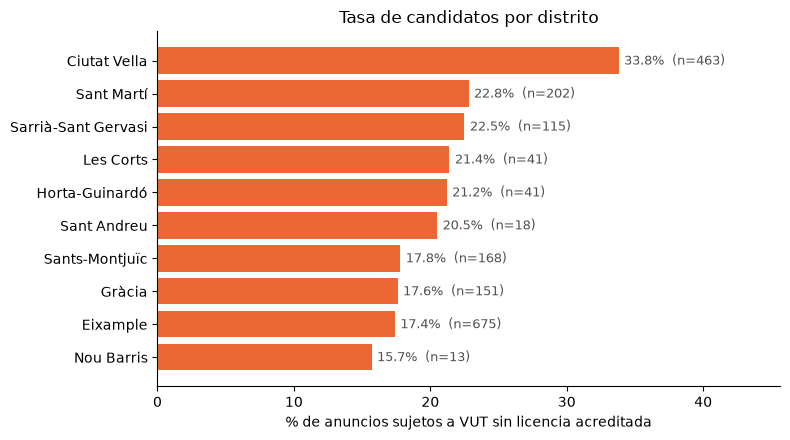

In [10]:
orden_pct = por_distrito.sort_values('% candidatos')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(orden_pct.index, orden_pct['% candidatos'], color='#eb6834')
for i, (pct, n) in enumerate(zip(orden_pct['% candidatos'], orden_pct['candidatos'])):
    ax.text(pct + 0.4, i, f'{pct}%  (n={n:,})', va='center', fontsize=9, color='#52514e')
ax.set_xlabel('% de anuncios sujetos a VUT sin licencia acreditada')
ax.set_title('Tasa de candidatos por distrito')
ax.set_xlim(0, orden_pct['% candidatos'].max() * 1.35)
for lado in ('top', 'right'):
    ax.spines[lado].set_visible(False)
plt.tight_layout()

In [11]:
por_host = candidatos.groupby(['host_id', 'host_name']).size().sort_values(ascending=False)
print(f'Anfitriones con algún candidato: {len(por_host):,}')
print(f'  con 1 anuncio : {(por_host == 1).sum():,}  → {por_host[por_host == 1].sum():,} anuncios')
print(f'  con 2-4       : {((por_host >= 2) & (por_host <= 4)).sum():,}  → {por_host[(por_host >= 2) & (por_host <= 4)].sum():,} anuncios')
print(f'  con 5 o más   : {(por_host >= 5).sum():,}  → {por_host[por_host >= 5].sum():,} anuncios')
print('\nLa mayoría de anfitriones tiene un solo anuncio, pero la mayoría de anuncios')
print('está en manos de unos pocos operadores. Son dos fenómenos distintos.')
por_host.head(10).to_frame('anuncios candidatos')

Anfitriones con algún candidato: 736
  con 1 anuncio : 587  → 587 anuncios
  con 2-4       : 103  → 270 anuncios
  con 5 o más   : 46  → 1,030 anuncios

La mayoría de anfitriones tiene un solo anuncio, pero la mayoría de anuncios
está en manos de unos pocos operadores. Son dos fenómenos distintos.


,,anuncios candidatos
host_id,host_name,
346367515.0,Ukio,352
1447144.0,Acomodis Apartments,117
21726991.0,Silvia De Lourdes,103
32037490.0,Sweett,58
64805231.0,Marc,32
397090058.0,Caterina,31
250042982.0,Miki,31
396363.0,Alcam Apartments,18
234256283.0,Francesc,18


## 6. Por qué el cruce por dirección no resuelve más

Sería lo natural para rescatar candidatos cuya licencia existe pero está mal escrita. **No es viable con estos datos**, y conviene dejar escrito por qué:

- Inside Airbnb **desplaza cada coordenada un punto aleatorio en un radio de ~200 m**, precisamente para impedir identificar la vivienda. En el Eixample ese radio abarca varias manzanas y decenas de licencias.
- Inside Airbnb **no publica dirección**, solo esa coordenada ofuscada y el barrio.

Un cruce espacial diría "hay 40 licencias cerca", no "esta es su licencia". Y afirmar lo segundo sería justo lo que `docs/prd.md` prohíbe. La vía practicable es la contraria: agregar por barrio y comparar volúmenes, no emparejar unidades.

In [12]:
# Comparación agregada por barrio: anuncios sujetos a VUT frente a licencias registradas.
vut = pd.read_csv(RAIZ / 'data/processed/vut_unificados.csv', dtype=str)
lic_barrio = (vut[vut['barrio'].notna()].groupby('barrio').size()
              .rename('licencias_registradas'))
anun_barrio = sujetos.groupby('neighbourhood').size().rename('anuncios_sujetos_vut')

comp = pd.concat([anun_barrio, lic_barrio], axis=1).dropna()
comp['ratio'] = (comp['anuncios_sujetos_vut'] / comp['licencias_registradas']).round(2)
print('Barrios donde se anuncia más de lo registrado (ratio > 1):')
comp[comp['ratio'] > 1].sort_values('ratio', ascending=False).head(12)

Barrios donde se anuncia más de lo registrado (ratio > 1):


,anuncios_sujetos_vut,licencias_registradas,ratio
la Guineueta,5.0,1.0,5.00
Vilapicina i la Torre Llobeta,60.0,17.0,3.53
el Turó de la Peira,3.0,1.0,3.00
la Marina de Port,23.0,8.0,2.88
el Congrés i els Indians,15.0,6.0,2.50
el Bon Pastor,5.0,2.0,2.50
la Vall d'Hebron,2.0,1.0,2.00
el Barri Gòtic,378.0,239.0,1.58
les Roquetes,3.0,2.0,1.50
el Raval,358.0,248.0,1.44


## Conclusiones

**Lo que se puede afirmar**

- El cruce con el registro oficial funciona: dos tercios de los anuncios sujetos a licencia la acreditan verificablemente.
- Hay licencias declaradas **numéricamente imposibles**, por encima del último número emitido. El error de tecleo no lo explica.
- La concentración es muy desigual: la mayoría de anfitriones tiene un anuncio, pero la mayoría de anuncios está en manos de unos pocos operadores.
- Existe un grupo llamativo justo en **31 noches**, el último valor dentro del régimen VUT.

**Lo que NO se puede afirmar**

- Que un candidato sea ilegal. El campo lo rellena el anfitrión sin validación: una licencia real mal escrita cae en el mismo grupo.
- Que la lista esté al día. El snapshot es de junio de 2026 y el registro se consultó en agosto; parte de las discrepancias es puro desfase.
- Nada sobre una vivienda concreta: las coordenadas están ofuscadas y el cruce es agregado.
- Que cubra el mercado: solo Airbnb. Booking y el resto quedan fuera.

**Siguiente paso para [M-08]:** el mapa de clusters con la columna `situacion`, y la agregación por barrio en `export.py` para lo que se publique.